# P01 - L1 vs. L2 planner comparison

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Verificar, com dados de campanha reais (nunca reexecutados nesta celula),
se o planner L2 (iterative_analytical) reduz os falsos negativos
documentados para L1 (conservative_one_round) no achado central do
manuscrito ICC 2027 (`docs/false_rejection_root_cause.md`): 100% das
rejeicoes oracle-testadas (240/240) no `three_node_1_repeater` eram na
verdade satisfazveis.

## Conceitos
- L1: `planning.purification.PurifyUntilTarget`, exatamente uma rodada
  analitica de `BBPSSWCircuit.improved_fidelity`.
- L2: `planning.planners.l2_iterative.IterativeAnalyticalPurification`,
  ate `max_rounds` rodadas iterativas (docs/l2_iterative_model.md).
- Campanha P01 (`configs/campaigns/planner_study/P01_*.yaml`): mesma
  topologia fisica de F03 (three_node_1_repeater / linear_chain_2_repeaters),
  mesmos 20 seeds, mesmo limiar de fidelidade densificado - apenas a
  politica de purificacao muda entre L1 e L2.

## Limitacoes
Ver `docs/planner_threats_to_validity.md` - esta comparacao usa taxas
diretas pareadas por seed, nao ainda o aparato estatistico completo
(paired-t/Wilcoxon/Holm) que P09 aplicara sobre toda a familia L1-L5.

## Configuracao

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.parent if (Path.cwd().name == "planner_study") else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "results" / "planner_study" / "processed"
RAW_DIR = PROJECT_ROOT / "results" / "planner_study" / "raw"

cells_df = pd.read_csv(PROCESSED_DIR / "P01_l1_l2_comparison.csv")
resolution_df = pd.read_csv(PROCESSED_DIR / "P01_l1_l2_false_rejection_resolution.csv")
cells_df.head()

,topology,planner_level,min_fidelity,n,satisfied,rejected,violated,satisfaction_rate,rejection_rate,mean_abs_fidelity_error,mean_planning_time_s
0,three_node,L1,0.650,20,20,0,0,1.0,0.0,0.0,0.000836
1,three_node,L1,0.700,20,20,0,0,1.0,0.0,0.0,0.000799
2,three_node,L1,0.720,20,20,0,0,1.0,0.0,0.0,0.000791
3,three_node,L1,0.730,20,0,20,0,0.0,1.0,NaN,0.000682
4,three_node,L1,0.735,20,0,20,0,0.0,1.0,NaN,0.000621


## Execucao
Dados ja persistidos por `scripts/analyze_p01_l1_l2.py` - nenhuma campanha e reexecutada aqui.

In [2]:
import json
overall = json.loads((PROCESSED_DIR / "P01_l1_l2_overall_summary.json").read_text())
overall

{'three_node_l1_rejection_rate_overall': 0.625,
 'three_node_l2_rejection_rate_overall': 0.0,
 'four_node_l1_rejection_rate_overall': 1.0,
 'four_node_l2_rejection_rate_overall': 0.5}

## Resultados

In [3]:
pivot = cells_df.pivot_table(
    index=["topology", "min_fidelity"], columns="planner_level",
    values=["rejection_rate", "satisfaction_rate", "mean_abs_fidelity_error", "mean_planning_time_s"],
)
pivot

mean_abs_fidelity_error                \
planner_level                                L1            L2   
topology   min_fidelity                                         
four_node  0.650                            NaN  0.000000e+00   
           0.700                            NaN -2.926007e-02   
           0.720                            NaN           NaN   
           0.730                            NaN           NaN   
           0.735                            NaN           NaN   
           0.740                            NaN           NaN   
           0.745                            NaN           NaN   
           0.750                            NaN           NaN   
three_node 0.650                            0.0  0.000000e+00   
           0.700                            0.0  0.000000e+00   
           0.720                            0.0  0.000000e+00   
           0.730                            NaN  2.220446e-17   
           0.735                            NaN  2.220446e-17   
           0.740                            NaN  2.220446e-17   
           0.745                            NaN  2.220446e-17   
           0.750                            NaN  2.220446e-17   

                        mean_planning_time_s           rejection_rate       \
planner_level                             L1        L2             L1   L2   
topology   min_fidelity                                                      
four_node  0.650                    0.000767  0.000957            1.0  0.0   
           0.700                    0.000689  0.000871            1.0  0.0   
           0.720                    0.000731  0.000961            1.0  0.0   
           0.730                    0.000642  0.000923            1.0  0.0   
           0.735                    0.000777  0.000844            1.0  1.0   
           0.740                    0.000746  0.000853            1.0  1.0   
           0.745                    0.000727  0.000858            1.0  1.0   
           0.750                    0.000730  0.000678            1.0  1.0   
three_node 0.650                    0.000836  0.000825            0.0  0.0   
           0.700                    0.000799  0.000793            0.0  0.0   
           0.720                    0.000791  0.000821            0.0  0.0   
           0.730                    0.000682  0.000890            1.0  0.0   
           0.735                    0.000621  0.000798            1.0  0.0   
           0.740                    0.000682  0.000981            1.0  0.0   
           0.745                    0.000730  0.000837            1.0  0.0   
           0.750                    0.000681  0.000725            1.0  0.0   

                        satisfaction_rate       
planner_level                          L1   L2  
topology   min_fidelity                         
four_node  0.650                      0.0  0.0  
           0.700                      0.0  0.0  
           0.720                      0.0  0.0  
           0.730                      0.0  0.0  
           0.735                      0.0  0.0  
           0.740                      0.0  0.0  
           0.745                      0.0  0.0  
           0.750                      0.0  0.0  
three_node 0.650                      1.0  1.0  
           0.700                      1.0  1.0  
           0.720                      1.0  1.0  
           0.730                      0.0  1.0  
           0.735                      0.0  1.0  
           0.740                      0.0  1.0  
           0.745                      0.0  1.0  
           0.750                      0.0  1.0

In [4]:
resolution_df

,requested_fidelity,l2_resolution_rate,topology,n_rejected_by_l1
0,0.730,1.0,three_node,20
1,0.735,1.0,three_node,20
2,0.740,1.0,three_node,20
3,0.745,1.0,three_node,20
4,0.750,1.0,three_node,20
5,0.650,0.0,four_node,20
6,0.700,0.0,four_node,20
7,0.720,0.0,four_node,20
8,0.730,0.0,four_node,20
9,0.735,0.0,four_node,20


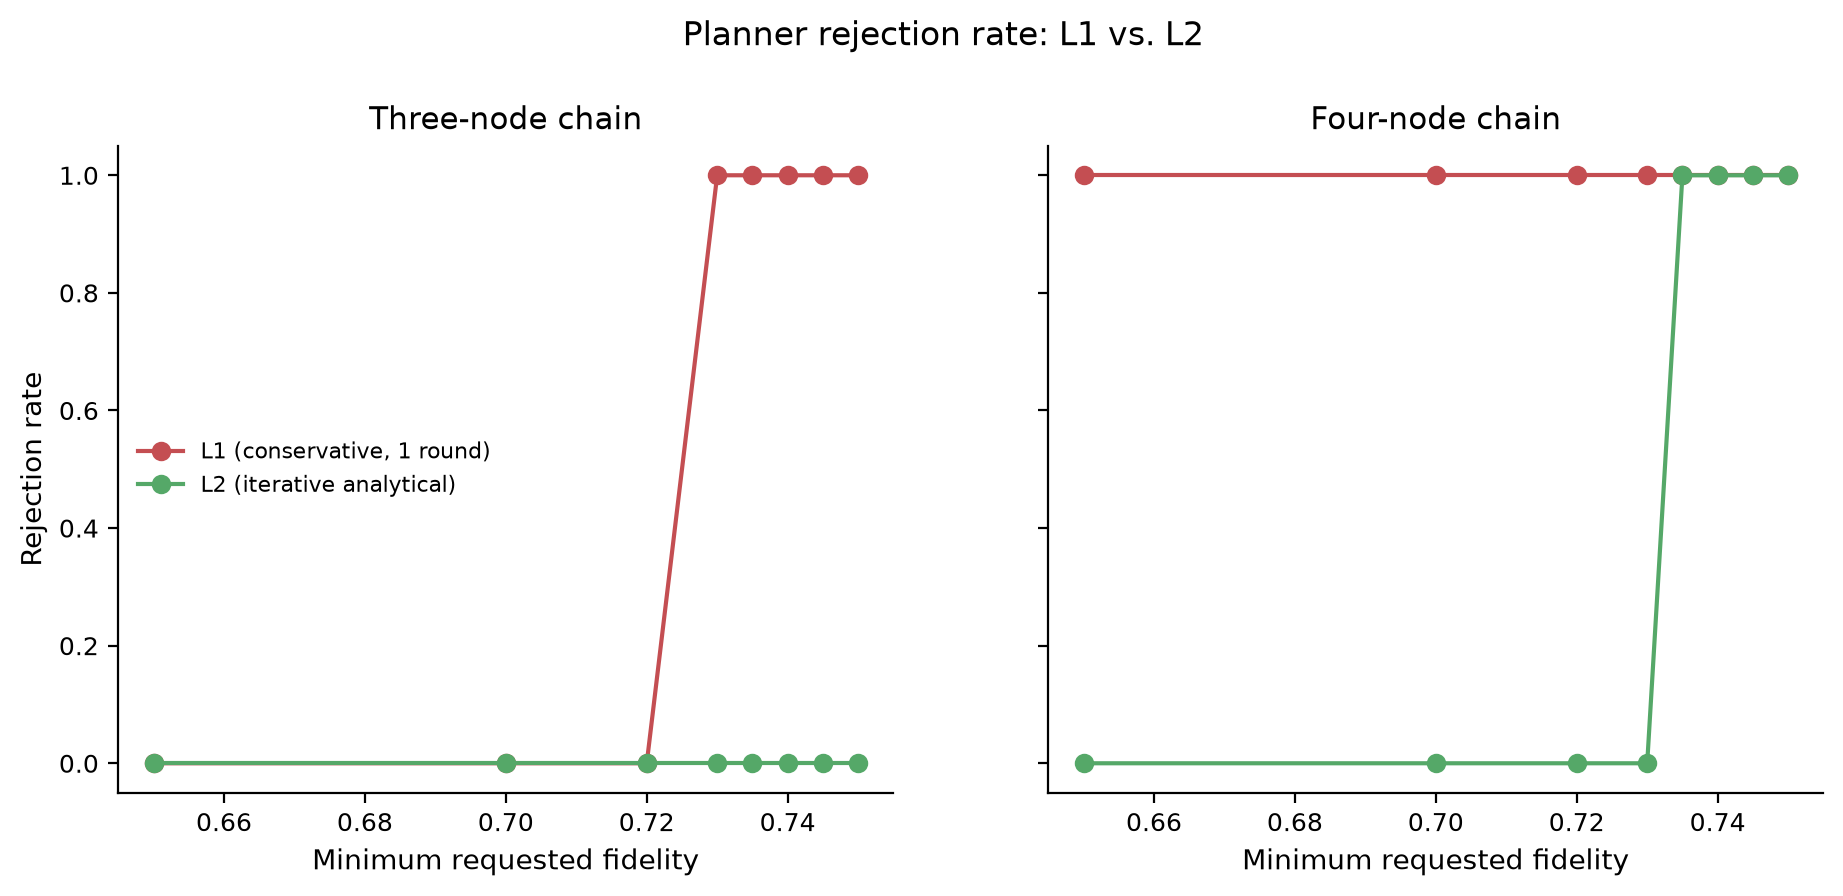

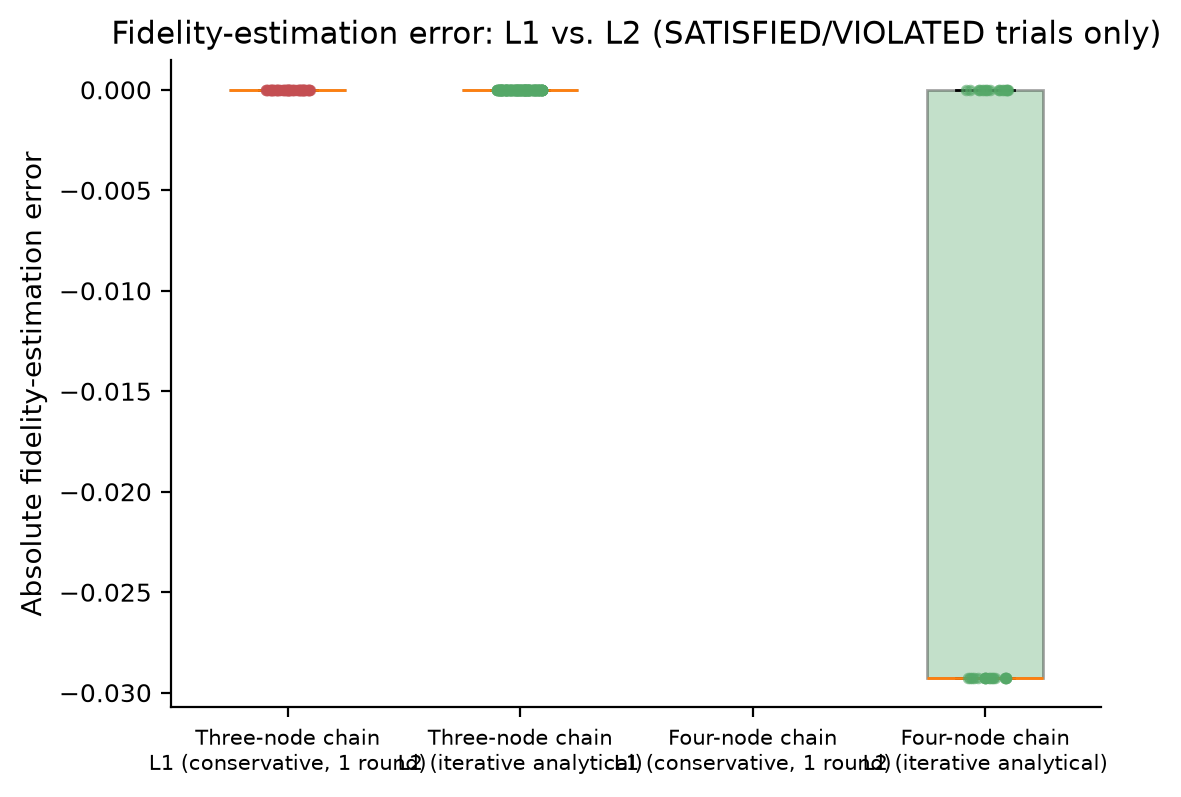

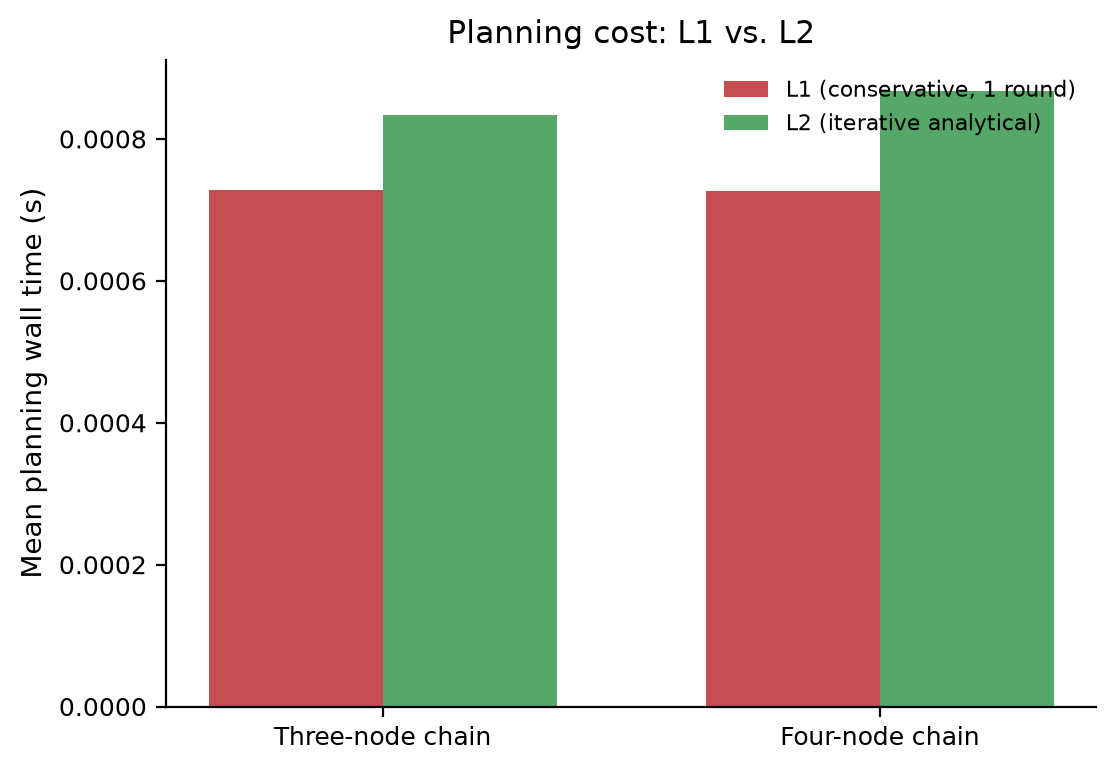

In [5]:
from IPython.display import Image, display
for name in ["P01_rejection_rate_by_level.png", "P01_fidelity_error_by_level.png", "P01_planning_time_by_level.png"]:
    display(Image(filename=str(PROJECT_ROOT / "results" / "planner_study" / "figures" / name)))

## Interpretacao
Ver `docs/planner_study_findings_checkpoint1.md` para a analise completa.
Resumo esperado: L2 deve resolver a faixa 0.73-0.75 no `three_node_1_repeater`
(onde L1 rejeita deterministicamente acima do teto de uma rodada,
0.7202522...), ao custo de mais tempo de planejamento (mais chamadas de
`BBPSSWCircuit.improved_fidelity`) e maior custo analitico de pares
(`cumulative_pair_cost`).

## Limitacoes
- Apenas duas topologias (three-node, four-node), ambas uniformes -
  nao generaliza a topologias heterogeneas (isso e o que a heterogeneidade
  do `diamond_heterogeneous` testaria, fora do escopo de P01).
- Taxas diretas, nao testes estatisticos formais (ver
  `docs/planner_threats_to_validity.md`).

## Conclusao
Ver `docs/planner_study_findings_checkpoint1.md`.